<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">14. State-Level Damage vs Rx5day Scatter</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Plots state-level (unaggregated) CWC flood damage against Rx5day across all 18 states to visually demonstrate the absence of a clean rainfall-damage relationship at this resolution, supporting the confounding-factor narrative.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'

cwc_long = pd.read_csv(OUTPUT_DIR + 'cwc_damage_deflated.csv')

print(cwc_long.shape)
print(cwc_long.columns.tolist())
print(cwc_long['state'].nunique() if 'state' in cwc_long.columns else 'no state column')
print(cwc_long.head())

(1278, 12)
['state', 'region', 'year', 'total_damages_cr', 'crops_damage_cr', 'houses_damage_cr', 'public_util_damage_cr', 'deflator_index', 'total_damages_cr_real_2022', 'crops_damage_cr_real_2022', 'houses_damage_cr_real_2022', 'public_util_damage_cr_real_2022']
18
               state     region  year  total_damages_cr  crops_damage_cr  \
0  Arunachal Pradesh  Northeast  1953               0.0              0.0   
1  Arunachal Pradesh  Northeast  1954               0.0              0.0   
2  Arunachal Pradesh  Northeast  1955               0.0              0.0   
3  Arunachal Pradesh  Northeast  1956               0.0              0.0   
4  Arunachal Pradesh  Northeast  1957               0.0              0.0   

   houses_damage_cr  public_util_damage_cr  deflator_index  \
0               0.0                    NaN             NaN   
1               0.0                    NaN             NaN   
2               0.0                    NaN             NaN   
3               0.0        

In [4]:
import geopandas as gpd
from shapely.ops import unary_union

path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")

# Fix 1: ensure the CWC renames are actually applied (Chattisgarh: known CWC-source spelling
# vs GADM's correct double-h; Delhi: CWC/RBI convention vs GADM's formal "NCT of Delhi")
cwc_long['state'] = cwc_long['state'].replace({
    'Chattisgarh': 'Chhattisgarh',
    'Delhi': 'NCT of Delhi'
})
cwc_states = cwc_long['state'].unique().tolist()

# Fix 2: union the two separate Arunachal Pradesh pieces
dupes = gdf[gdf['NAME_1'] == 'Arunachal Pradesh']
arunachal_union = unary_union(dupes.geometry.tolist())

gdf_states_dedup = gdf[gdf['NAME_1'].isin(cwc_states) & (gdf['NAME_1'] != 'Arunachal Pradesh')].copy()
arunachal_row = dupes.iloc[[0]].copy()
arunachal_row['geometry'] = [arunachal_union]

gdf_states = pd.concat([gdf_states_dedup, arunachal_row], ignore_index=True)

print(f"CWC states: {len(cwc_states)}")
print(f"Matched in GADM: {len(gdf_states)}")
print("Unmatched:", set(cwc_states) - set(gdf_states['NAME_1']))

CWC states: 18
Matched in GADM: 18
Unmatched: set()


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: State-Level Rx5day from ERA5</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Computes area-weighted Rx5day per state (not aggregated to the four study regions) using the same ERA5 gridded Rx5day and fractional-overlap masking approach used throughout the project, so state-level rainfall can be compared against state-level CWC damage.</p>
</div>

In [6]:
import regionmask
import xarray as xr

state_names = gdf_states['NAME_1'].tolist()
states_mask_obj = regionmask.Regions(
    gdf_states.geometry.tolist(),
    names=state_names,
    abbrevs=[s[:3] for s in state_names]
)

# Load ERA5 gridded Rx5day (same file used throughout the project)
rx5day_era5 = xr.open_dataarray(OUTPUT_DIR + 'rx5day_jjas_era5_1981_2023.nc')

frac_overlap_states = states_mask_obj.mask_3D_frac_approx(
    rx5day_era5.longitude.values, rx5day_era5.latitude.values
)
frac_overlap_states = frac_overlap_states.assign_coords(region=state_names)

print('State-level masks built on ERA5 grid')
print(f'States: {state_names}')

# Quick check: total weighted coverage per state (flag any near-zero)
weight_totals = frac_overlap_states.sum(dim=['lat', 'lon'])
print('\nWeighted grid-cell coverage per state:')
for s, w in zip(state_names, weight_totals.values):
    print(f'  {s}: {w:.2f}')

State-level masks built on ERA5 grid
States: ['Assam', 'Bihar', 'Chhattisgarh', 'Goa', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'NCT of Delhi', 'Odisha', 'Punjab', 'Tripura', 'Uttar Pradesh', 'West Bengal', 'Arunachal Pradesh']

Weighted grid-cell coverage per state:
  Assam: 113.60
  Bihar: 135.69
  Chhattisgarh: 188.58
  Goa: 4.97
  Haryana: 65.40
  Jharkhand: 113.27
  Karnataka: 257.05
  Kerala: 49.82
  Madhya Pradesh: 435.98
  Maharashtra: 423.33
  Meghalaya: 32.33
  NCT of Delhi: 2.21
  Odisha: 215.74
  Punjab: 75.67
  Tripura: 14.92
  Uttar Pradesh: 350.28
  West Bengal: 121.08
  Arunachal Pradesh: 120.29


In [7]:
YEAR_START, YEAR_END = 2000, 2020  # matches the standard CWC-constrained window

rx5day_era5_renamed = rx5day_era5.rename({'latitude': 'lat', 'longitude': 'lon'})

rx5day_state_records = []
for state in state_names:
    weights = frac_overlap_states.sel(region=state)
    weight_total = weights.sum(dim=['lat', 'lon'])

    for yr in range(YEAR_START, YEAR_END + 1):
        rx5day_yr = rx5day_era5_renamed.sel(year=yr)
        weighted_val = (rx5day_yr * weights).sum(dim=['lat', 'lon']) / weight_total
        rx5day_state_records.append({'state': state, 'year': yr, 'rx5day_mm': float(weighted_val)})

rx5day_state_df = pd.DataFrame(rx5day_state_records)
print(rx5day_state_df.groupby('state')['rx5day_mm'].describe()[['mean', 'min', 'max']])

                         mean         min         max
state                                                
Arunachal Pradesh  285.736478  218.064958  365.967073
Assam              245.171264  168.826158  348.013200
Bihar              178.945815  117.939334  277.620565
Chhattisgarh       204.287114  169.747620  254.701472
Goa                352.307168  232.914921  444.390745
Haryana            108.756784   77.146048  169.095810
Jharkhand          153.275724   93.303632  242.993013
Karnataka          123.199178   94.966665  161.001207
Kerala             216.231822  154.897184  309.119693
Madhya Pradesh     189.744141  121.397326  261.573609
Maharashtra        195.485984  140.083585  260.670711
Meghalaya          277.987390  167.178598  400.517307
NCT of Delhi       109.710017   72.644632  167.127981
Odisha             205.347164  145.734507  273.627367
Punjab             100.883117   61.327194  178.692229
Tripura            153.198082   95.683748  240.714751
Uttar Pradesh      162.09886

In [8]:
# Save state-level Rx5day so it doesn't need recomputing on kernel restart
rx5day_state_df.to_csv(OUTPUT_DIR + 'rx5day_state_df.csv', index=False)
print('Saved rx5day_state_df for reuse')

Saved rx5day_state_df for reuse


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: State-Level Scatter, Damage vs Rx5day</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Merges state-level Rx5day with CWC total damage (2000-2020) and plots all 18 states unaggregated, to visually assess whether a clean rainfall-damage relationship exists at this resolution.</p>
</div>

In [9]:
cwc_2000_2020 = cwc_long[(cwc_long.year >= YEAR_START) & (cwc_long.year <= YEAR_END)]
merged_state = cwc_2000_2020.merge(rx5day_state_df, on=['state', 'year'])
print(f"Merged rows: {len(merged_state)}")

Merged rows: 378


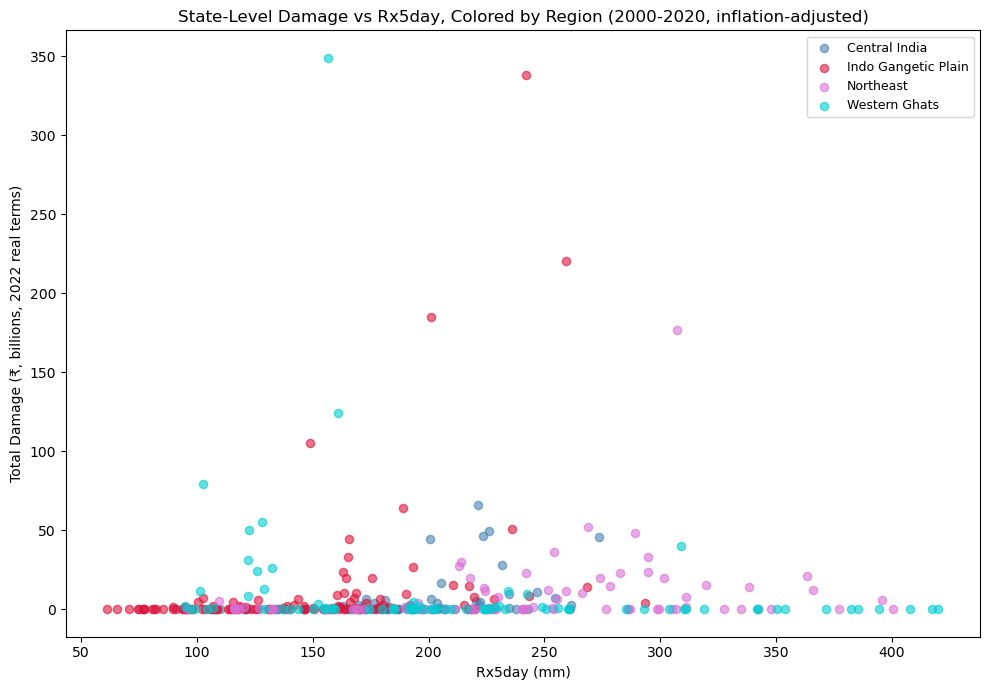

In [10]:
region_colors_map = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}

merged_state['total_damages_inr_bn'] = merged_state['total_damages_cr_real_2022'] * 1e7 / 1e9

fig, ax = plt.subplots(figsize=(10, 7))

for region, color in region_colors_map.items():
    sub = merged_state[merged_state.region == region]
    ax.scatter(sub.rx5day_mm, sub.total_damages_inr_bn, alpha=0.6, s=35,
               color=color, label=region.replace('_', ' '))

ax.set_xlabel('Rx5day (mm)')
ax.set_ylabel('Total Damage (₹, billions, 2022 real terms)')
ax.set_title('State-Level Damage vs Rx5day, Colored by Region (2000-2020, inflation-adjusted)')
ax.legend(fontsize=9)
plt.tight_layout()
# Reported in the dissertation as Figure 22
plt.savefig(OUTPUT_DIR + 'figure22_state_scatter_colored_real2022.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("Total rows:", len(merged_state))
print("NaN in rx5day_mm:", merged_state.rx5day_mm.isna().sum())
print("NaN in total_damages_cr_real_2022:", merged_state.total_damages_cr_real_2022.isna().sum())
print()
print(merged_state[merged_state.total_damages_cr_real_2022.isna()][['state', 'year']])

Total rows: 378
NaN in rx5day_mm: 0
NaN in total_damages_cr_real_2022: 22

                 state  year
19   Arunachal Pradesh  2019
61               Bihar  2019
63        Chhattisgarh  2000
82        Chhattisgarh  2019
102                Goa  2018
103                Goa  2019
104                Goa  2020
110            Haryana  2005
125            Haryana  2020
126          Jharkhand  2000
166          Karnataka  2019
167          Karnataka  2020
187             Kerala  2019
251          Meghalaya  2020
292             Punjab  2019
352        West Bengal  2016
372       NCT of Delhi  2015
373       NCT of Delhi  2016
374       NCT of Delhi  2017
375       NCT of Delhi  2018
376       NCT of Delhi  2019
377       NCT of Delhi  2020


In [12]:
from scipy.stats import pearsonr, spearmanr

clean = merged_state.dropna(subset=['rx5day_mm', 'total_damages_cr_real_2022'])
print(f"Clean rows: {len(clean)} (dropped {len(merged_state) - len(clean)})")

r_p, p_p = pearsonr(clean.rx5day_mm, clean.total_damages_cr_real_2022)
r_s, p_s = spearmanr(clean.rx5day_mm, clean.total_damages_cr_real_2022)
print(f"Pearson r = {r_p:.3f} (p={p_p:.4f})")
print(f"Spearman r = {r_s:.3f} (p={p_s:.4f})")

Clean rows: 356 (dropped 22)
Pearson r = 0.076 (p=0.1499)
Spearman r = 0.180 (p=0.0007)


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: GDP-Normalization Test</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Tests whether normalizing damage by state economic size (NSDP) tightens the rainfall-damage relationship established in Part 2, the original motivation for commissioning state-level GDP data.</p>
</div>

In [ ]:
# GDP-Normalization Test
# Tests whether normalizing damage by state economic size (NSDP) tightens the
# rainfall-damage correlation, the original motivation for commissioning
# state-level GDP data. Uses the single-year (2019-20) NSDP snapshot from
# notebook 16 applied as a constant across all 21 years: a deliberate 
# cross-sectional/temporal mismatch,
# consistent with how the exposure snapshot is treated elsewhere in this project.

nsdp_state = pd.read_csv(OUTPUT_DIR + 'nsdp_state_breakdown_by_region.csv')
print(nsdp_state.columns.tolist())  # confirm actual columns before merging

# nsdp_state uses RBI naming ('Delhi'); merged_state uses GADM naming ('NCT of Delhi',
# from this notebook's earlier fix). Reverse-map locally for this merge only.
merged_gdp = merged_state.copy()
merged_gdp['state_rbi_name'] = merged_gdp['state'].replace({'NCT of Delhi': 'Delhi'})

merged_gdp = merged_gdp.merge(
    nsdp_state[['state', 'nsdp_current_prices_rs_crore']],
    left_on='state_rbi_name', right_on='state', how='left', suffixes=('', '_nsdp')
)

n_unmatched = merged_gdp['nsdp_current_prices_rs_crore'].isna().sum()
print(f"\nRows with no NSDP match: {n_unmatched}")
if n_unmatched > 0:
    print(merged_gdp[merged_gdp['nsdp_current_prices_rs_crore'].isna()]['state'].unique())

merged_gdp['damage_pct_of_nsdp'] = (
    merged_gdp['total_damages_cr_real_2022'] / merged_gdp['nsdp_current_prices_rs_crore'] * 100
)

clean_gdp = merged_gdp.dropna(subset=['rx5day_mm', 'damage_pct_of_nsdp'])
print(f"\nClean rows: {len(clean_gdp)} (dropped {len(merged_gdp) - len(clean_gdp)})")

r_p_gdp, p_p_gdp = pearsonr(clean_gdp.rx5day_mm, clean_gdp.damage_pct_of_nsdp)
r_s_gdp, p_s_gdp = spearmanr(clean_gdp.rx5day_mm, clean_gdp.damage_pct_of_nsdp)
print(f"\nGDP-normalized (damage as % of state NSDP):")
print(f"Pearson r = {r_p_gdp:.3f} (p={p_p_gdp:.4f})")
print(f"Spearman r = {r_s_gdp:.3f} (p={p_s_gdp:.4f})")

print(f"\nFor comparison, raw (real-2022) damage:")
print(f"Pearson r = {r_p:.3f} (p={p_p:.4f})")
print(f"Spearman r = {r_s:.3f} (p={p_s:.4f})")

['state', 'nsdp_current_prices_rs_crore', 'region', 'state_share_of_national_pct', 'region_total_nsdp', 'state_share_of_region_pct']

Rows with no NSDP match: 0

Clean rows: 356 (dropped 22)

GDP-normalized (damage as % of state NSDP):
Pearson r = 0.187 (p=0.0004)
Spearman r = 0.235 (p=0.0000)

For comparison, raw (real-2022) damage:
Pearson r = 0.076 (p=0.1499)
Spearman r = 0.180 (p=0.0007)


In [15]:
clean_gdp[clean_gdp.damage_pct_of_nsdp > 30][['state', 'year', 'rx5day_mm', 'total_damages_cr_real_2022', 'nsdp_current_prices_rs_crore', 'damage_pct_of_nsdp']]

,state,year,rx5day_mm,total_damages_cr_real_2022,nsdp_current_prices_rs_crore,damage_pct_of_nsdp
3,Arunachal Pradesh,2003,307.256959,17700.760208,27526.08,64.305416


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: CWC Descriptive Analysis (National & Regional)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Descriptive analysis of the CWC damage dataset: national total damage over time, its breakdown between crop, house, and public utility damage categories, and regional cuts of regional total damage over time with a state-level subdivision, and category composition by region.</p>
</div>

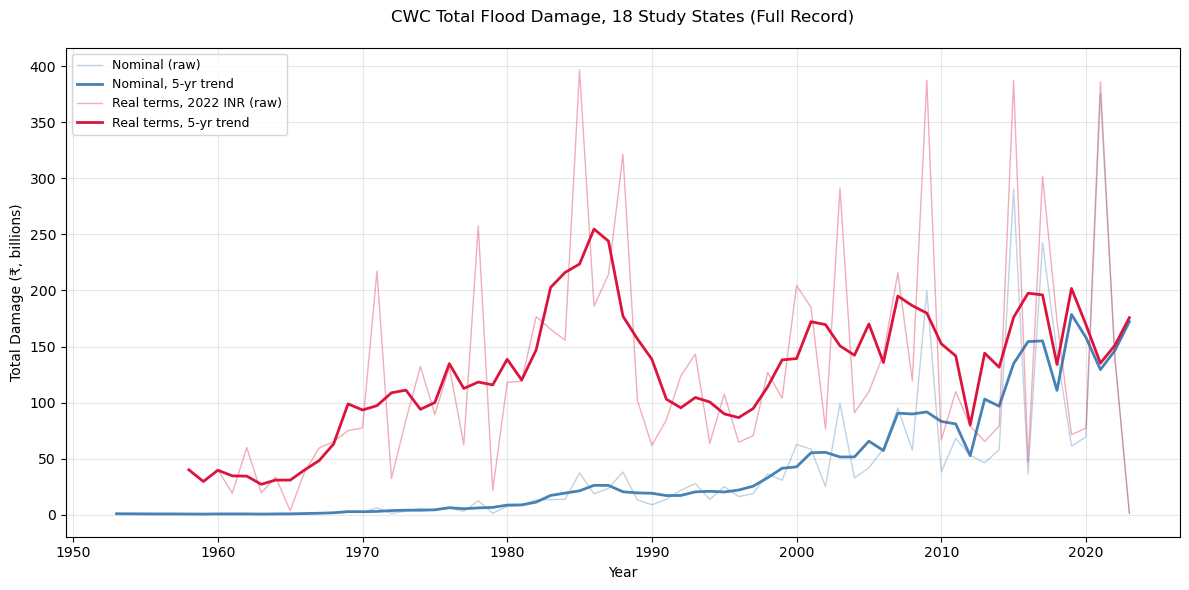

In [17]:
national_annual = cwc_long.groupby('year')[['total_damages_cr', 'total_damages_cr_real_2022']].sum(min_count=1)

national_annual['nominal_inr_bn'] = national_annual['total_damages_cr'] * 1e7 / 1e9
national_annual['real2022_inr_bn'] = national_annual['total_damages_cr_real_2022'] * 1e7 / 1e9
national_annual['nominal_trend'] = national_annual['nominal_inr_bn'].rolling(5, center=True, min_periods=1).mean()
national_annual['real2022_trend'] = national_annual['real2022_inr_bn'].rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(national_annual.index, national_annual['nominal_inr_bn'], color='steelblue', linewidth=1, alpha=0.35, label='Nominal (raw)')
ax.plot(national_annual.index, national_annual['nominal_trend'], color='steelblue', linewidth=2, label='Nominal, 5-yr trend')
ax.plot(national_annual.index, national_annual['real2022_inr_bn'], color='crimson', linewidth=1, alpha=0.35, label='Real terms, 2022 INR (raw)')
ax.plot(national_annual.index, national_annual['real2022_trend'], color='crimson', linewidth=2, label='Real terms, 5-yr trend')

ax.set_xlabel('Year')
ax.set_ylabel('Total Damage (₹, billions)')
ax.set_title('CWC Total Flood Damage, 18 Study States (Full Record)\n')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_cwc_national_timeseries_real2022.png', dpi=150, bbox_inches='tight')
plt.show()

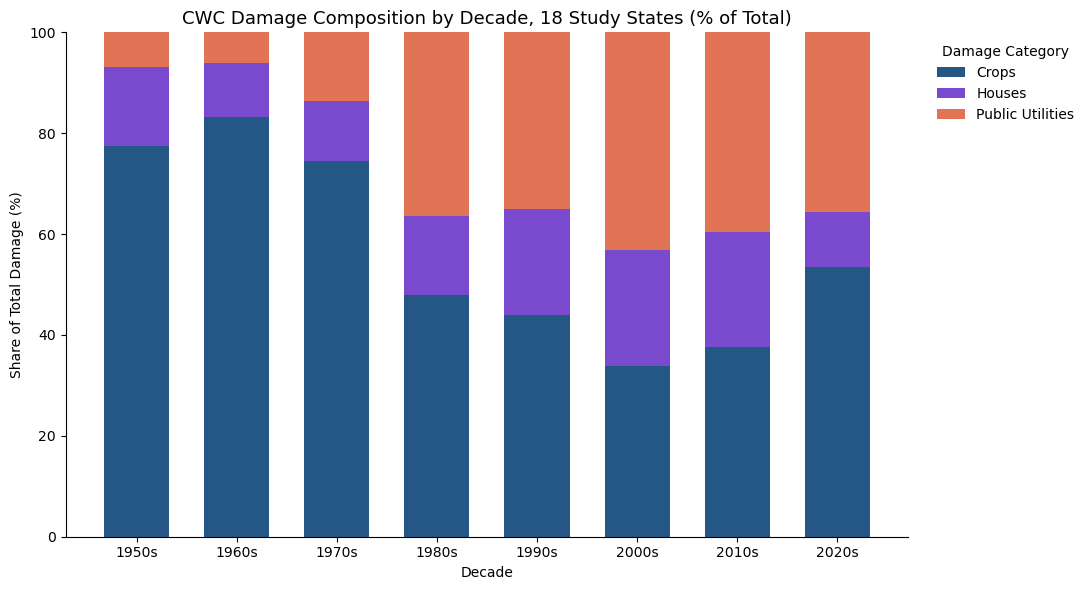

In [19]:
cwc_long['decade'] = (cwc_long['year'] // 10) * 10
decade_totals = cwc_long.groupby('decade')[['crops_damage_cr', 'houses_damage_cr', 'public_util_damage_cr']].sum(min_count=1)
decade_totals['total'] = decade_totals.sum(axis=1)
decade_totals['crops_pct'] = 100 * decade_totals.crops_damage_cr / decade_totals.total
decade_totals['houses_pct'] = 100 * decade_totals.houses_damage_cr / decade_totals.total
decade_totals['putil_pct'] = 100 * decade_totals.public_util_damage_cr / decade_totals.total

decade_labels = [f"{d}s" for d in decade_totals.index]

fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#053F75DF", "#5B22C4D1", "#DB562ED1"]
categories = ['crops_pct', 'houses_pct', 'putil_pct']
labels = ['Crops', 'Houses', 'Public Utilities']

bottom = np.zeros(len(decade_totals))
for col, color, label in zip(categories, colors, labels):
    ax.bar(decade_labels, decade_totals[col], bottom=bottom, color=color, label=label, width=0.65)
    bottom += decade_totals[col].values

ax.set_ylim(0, 100)
ax.set_ylabel('Share of Total Damage (%)')
ax.set_xlabel('Decade')
ax.set_title('CWC Damage Composition by Decade, 18 Study States (% of Total)', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Damage Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_cwc_category_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

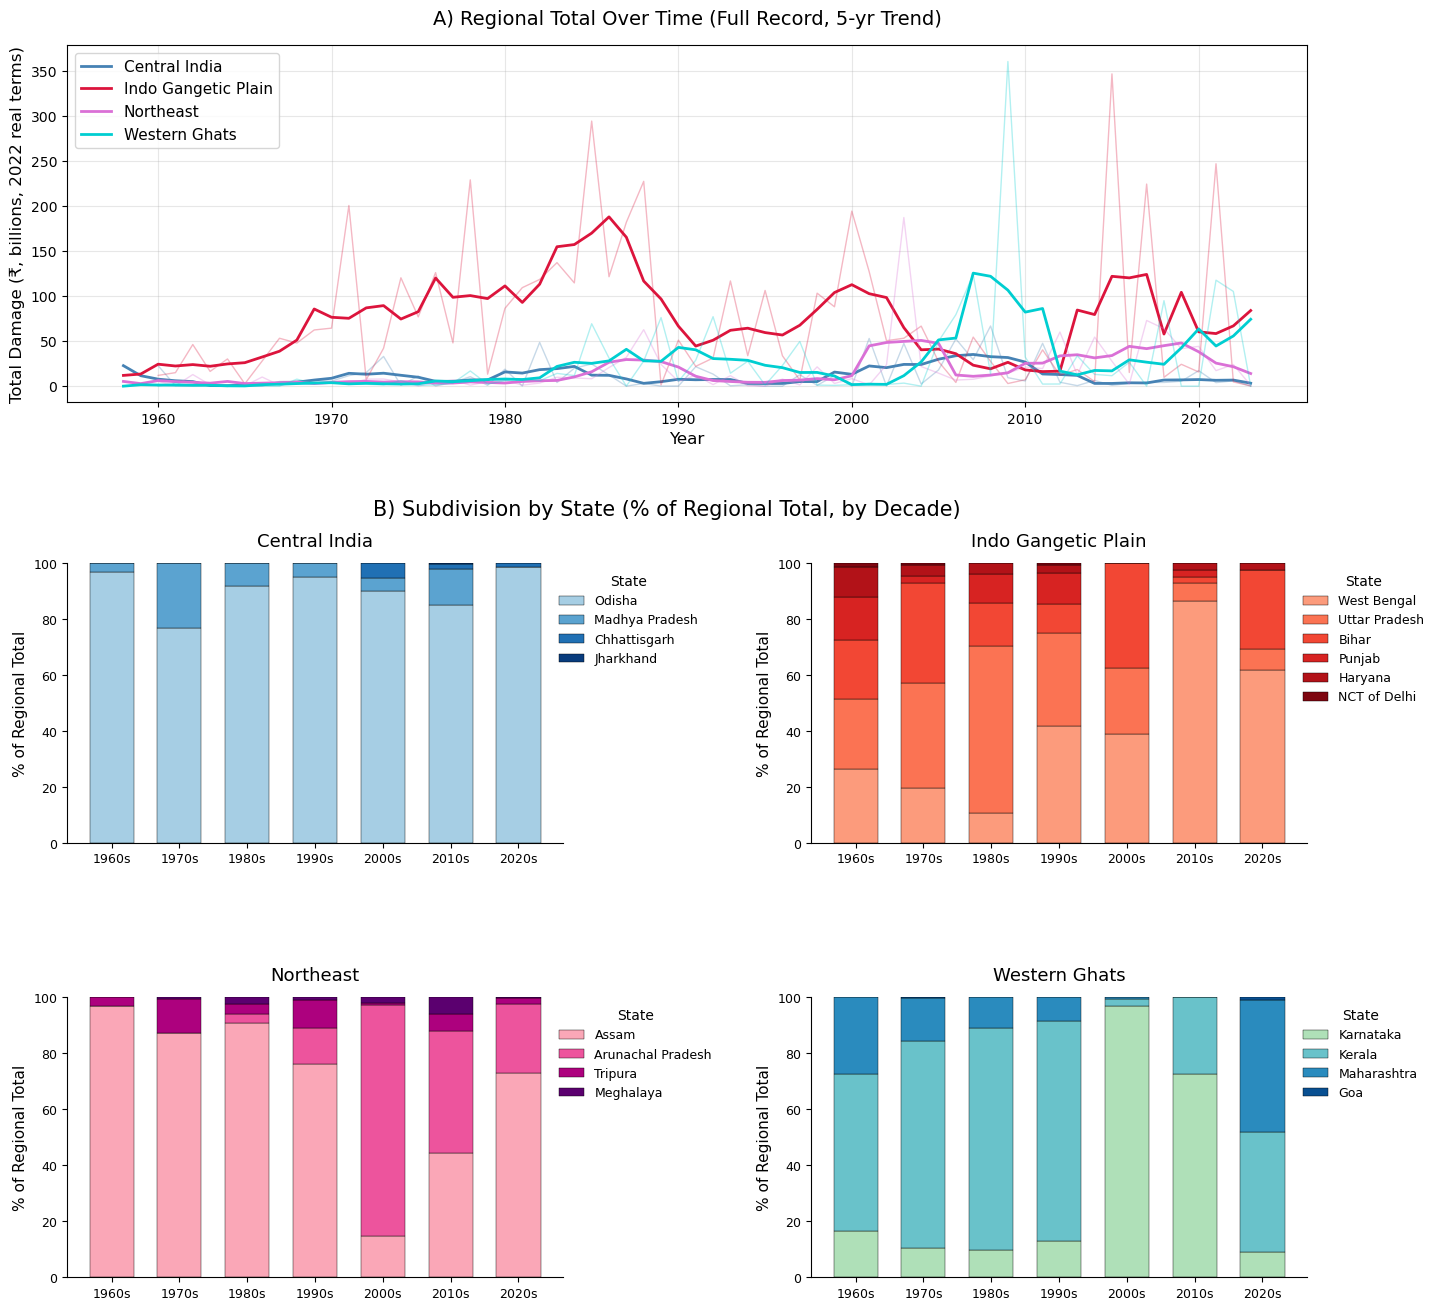

In [24]:
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

region_colors_map = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}
region_cmaps = {
    'Central_India': cm.Blues,
    'Indo_Gangetic_Plain': cm.Reds,
    'Northeast': cm.RdPu,
    'Western_Ghats': cm.GnBu,
}
regions_order = list(region_colors_map.keys())

# Manual colour overrides: (region, state) hex or named colour.
# Any state NOT listed here falls back to the automatic colormap shading.
MANUAL_STATE_COLORS = {
    # ('Indo_Gangetic_Plain', 'NCT of Delhi'): '#4A0E0E',
    # ('Western_Ghats', 'Goa'): '#006D6D',
}

cwc_long['total_damages_inr_bn'] = cwc_long['total_damages_cr_real_2022'] * 1e7 / 1e9
cwc_long['decade'] = (cwc_long['year'] // 10) * 10

region_annual = cwc_long.groupby(['region', 'year'])['total_damages_inr_bn'].sum(min_count=1).reset_index()
decade_state = cwc_long.groupby(['region', 'state', 'decade'])['total_damages_inr_bn'].sum(min_count=1).reset_index()

fig = plt.figure(figsize=(16, 16))
gs = GridSpec(2, 1, height_ratios=[1.0, 2.0], hspace=0.3)

# Panel A
ax_top = fig.add_subplot(gs[0])
for region, color in region_colors_map.items():
    sub = region_annual[region_annual.region == region].sort_values('year')
    trend = sub['total_damages_inr_bn'].rolling(5, center=True, min_periods=1).mean()
    ax_top.plot(sub.year, sub.total_damages_inr_bn, color=color, linewidth=1, alpha=0.3, label='_nolegend_')
    ax_top.plot(sub.year, trend, color=color, linewidth=2, label=region.replace('_', ' '))
ax_top.set_xlabel('Year', fontsize=12)
ax_top.set_ylabel('Total Damage (₹, billions, 2022 real terms)', fontsize=12)
ax_top.set_title('A) Regional Total Over Time (Full Record, 5-yr Trend)', pad=15, fontsize=14)
ax_top.legend(fontsize=11)
ax_top.tick_params(axis='both', labelsize=10)
ax_top.grid(alpha=0.3)

# Panel B: subdivision by state, 2x2 grid 
inner_gs = GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], hspace=0.55, wspace=0.5)
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (row, col), region in zip(positions, regions_order):
    ax_r = fig.add_subplot(inner_gs[row, col])
    cmap = region_cmaps[region]

    pivot = decade_state[decade_state.region == region].pivot(index='decade', columns='state', values='total_damages_inr_bn')
    pivot = pivot.reindex(range(1960, 2030, 10))

    row_totals = pivot.sum(axis=1, skipna=True, min_count=1)
    pct = pivot.div(row_totals, axis=0) * 100

    totals_full_record = pivot.sum(skipna=True).sort_values(ascending=False)
    n = len(totals_full_record)

    colors = []
    for i, state in enumerate(totals_full_record.index):
        key = (region, state)
        if key in MANUAL_STATE_COLORS:
            colors.append(MANUAL_STATE_COLORS[key])
        else:
            colors.append(cmap(0.35 + 0.6 * i / max(n - 1, 1)))

    decade_labels = [f"{int(d)}s" for d in pct.index]
    bottom = np.zeros(len(pct))
    for state, color in zip(totals_full_record.index, colors):
        vals = pct[state].fillna(0).values
        ax_r.bar(decade_labels, vals, bottom=bottom, color=color, label=state, width=0.65,
                  edgecolor='black', linewidth=0.3)
        bottom += vals

    ax_r.set_ylim(0, 100)
    ax_r.set_ylabel('% of Regional Total', fontsize=11)
    ax_r.set_title(region.replace('_', ' '), fontsize=13, pad=12)
    ax_r.spines['top'].set_visible(False)
    ax_r.spines['right'].set_visible(False)
    ax_r.legend(title='State', bbox_to_anchor=(0.97, 1), loc='upper left', frameon=False, fontsize=9, title_fontsize=10)
    ax_r.tick_params(axis='both', labelsize=9)

fig.text(0.5, gs[1].get_position(fig).y1 + 0.03,
          'B) Subdivision by State (% of Regional Total, by Decade)', ha='center', fontsize=15)

plt.savefig(OUTPUT_DIR + 'figure_regional_2panel_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
nat = cwc_long.groupby('year')['total_damages_cr_real_2022'].sum(min_count=1) * 1e7 / 1e9
nat_nom = cwc_long.groupby('year')['total_damages_cr'].sum(min_count=1) * 1e7 / 1e9
tr = nat.rolling(5, center=True, min_periods=1).mean()

print("real trend peak:   ", tr.idxmax(), round(tr.max(), 1))
print("real annual peak:  ", nat.idxmax(), round(nat.max(), 1))
print("1990s trend trough:", tr.loc[1990:1999].idxmin(), round(tr.loc[1990:1999].min(), 1))
print("2000s trend peak:  ", tr.loc[2000:2009].idxmax(), round(tr.loc[2000:2009].max(), 1))
print("\n1960s mean:", round(nat.loc[1960:1969].mean(), 1),
      "| 2010s mean:", round(nat.loc[2010:2019].mean(), 1),
      "| ratio:", round(nat.loc[2010:2019].mean() / nat.loc[1960:1969].mean(), 1))

print("\n--- end of record ---")
print(cwc_long[cwc_long.year >= 2021].groupby('year').agg(
    reported=('total_damages_cr', 'count'),
    states=('state', 'nunique'),
    real_bn=('total_damages_cr_real_2022', lambda s: round(s.sum()*1e7/1e9, 1))))

print("\nstates in data:", cwc_long.state.nunique())
print(sorted(cwc_long.state.unique()))

real trend peak:    1986 254.8
real annual peak:   1985 396.8
1990s trend trough: 1996 86.6
2000s trend peak:   2007 195.1

1960s mean: 41.2 | 2010s mean: 138.0 | ratio: 3.3

--- end of record ---
      reported  states  real_bn
year                           
2021        15      18    386.1
2022         9      18    139.9
2023         9      18      1.1

states in data: 18
['Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'NCT of Delhi', 'Odisha', 'Punjab', 'Tripura', 'Uttar Pradesh', 'West Bengal']


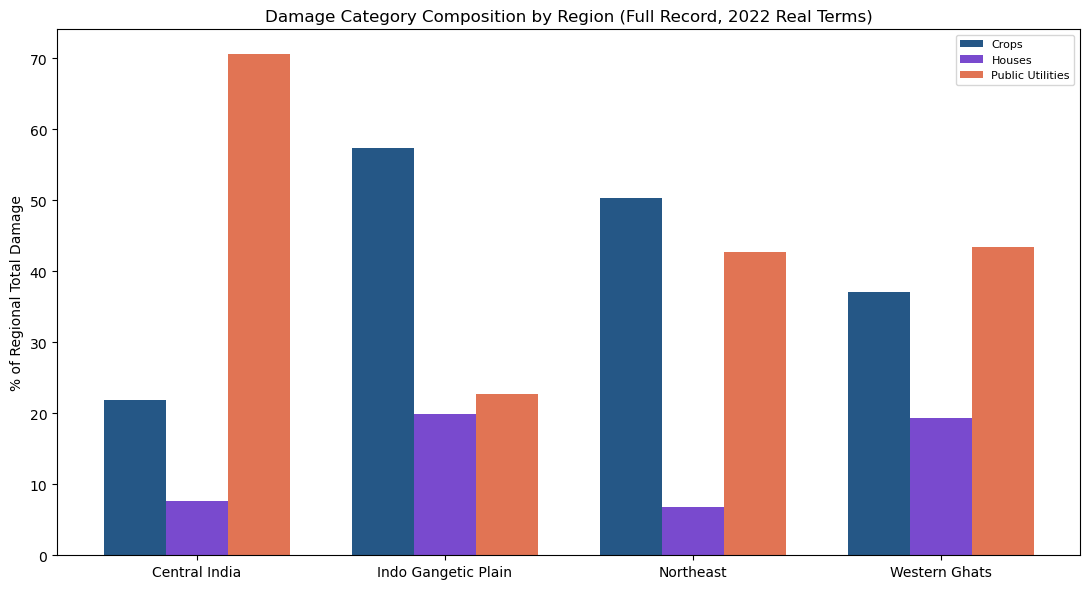

                     crops_pct  houses_pct  putil_pct
region                                               
Central_India             21.8         7.6       70.6
Indo_Gangetic_Plain       57.4        19.9       22.7
Northeast                 50.4         6.9       42.8
Western_Ghats             37.1        19.4       43.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

category_colors = ["#053F75DF", "#5B22C4D1", "#DB562ED1"]
regions_order = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = './outputs/'

# Deflated to 2022 real terms
# Nominal sums weight recent decades far more heavily and reverse the
# largest-category result in two of the four regions.
real_cols = ['crops_damage_cr_real_2022',
             'houses_damage_cr_real_2022',
             'public_util_damage_cr_real_2022']

regional_category_totals = cwc_long.groupby('region')[real_cols].sum(min_count=1)
regional_category_totals['total'] = regional_category_totals[real_cols].sum(axis=1)
regional_category_totals['crops_pct']  = 100 * regional_category_totals[real_cols[0]] / regional_category_totals['total']
regional_category_totals['houses_pct'] = 100 * regional_category_totals[real_cols[1]] / regional_category_totals['total']
regional_category_totals['putil_pct']  = 100 * regional_category_totals[real_cols[2]] / regional_category_totals['total']
regional_category_totals = regional_category_totals.reindex(regions_order)

fig_c, ax_c = plt.subplots(figsize=(11, 6))
x = np.arange(len(regions_order))
width = 0.25
for i, (col, color, label) in enumerate(zip(['crops_pct', 'houses_pct', 'putil_pct'],
                                            category_colors,
                                            ['Crops', 'Houses', 'Public Utilities'])):
    ax_c.bar(x + (i - 1) * width, regional_category_totals[col], width, color=color, label=label)

ax_c.set_xticks(x)
ax_c.set_xticklabels([r.replace('_', ' ') for r in regions_order])
ax_c.set_ylabel('% of Regional Total Damage')
ax_c.set_title('Damage Category Composition by Region (Full Record, 2022 Real Terms)')
ax_c.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_category_composition_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print(regional_category_totals[['crops_pct', 'houses_pct', 'putil_pct']].round(1))

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 5: Frequency vs Magnitude of Flood Damage</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Distinguishes whether floods are occurring more often over time, or whether the same frequency of floods is simply becoming more damaging when they occur. Computed as the fraction of state-years with recorded non-zero damage (excluding missing/NR years), by decade and region.</p>
</div>

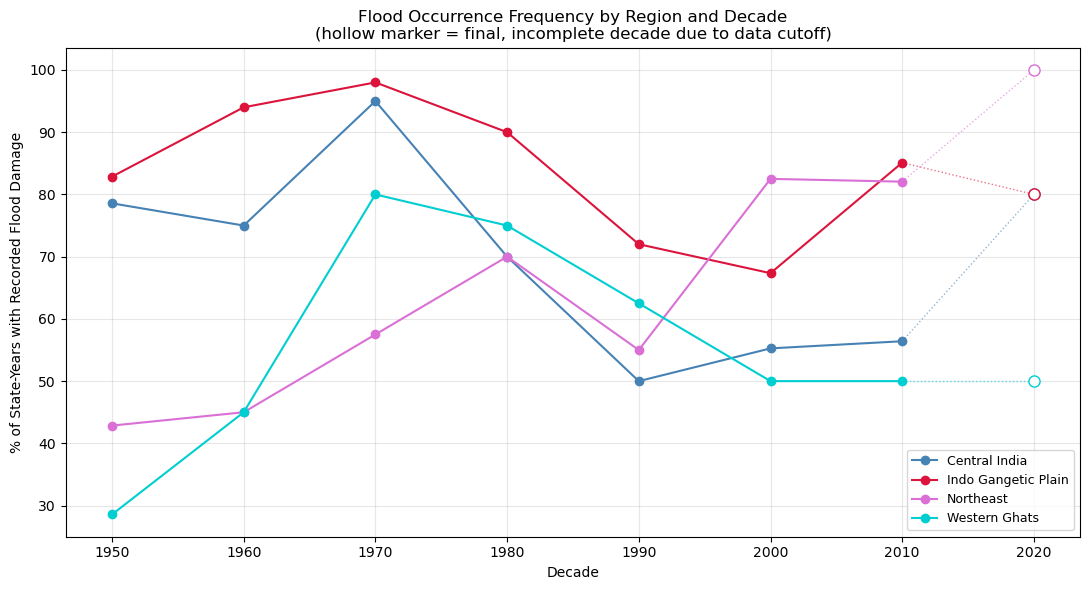

In [ ]:
# Only flag the FINAL decade in the record as "partial" (the genuine data-cutoff truncation)
# not 1950, which is naturally smaller because the record starts in 1953, not because of missing data
max_decade = freq_by_region_decade['decade'].max()
freq_by_region_decade['is_partial'] = freq_by_region_decade['decade'] == max_decade

fig, ax = plt.subplots(figsize=(11, 6))
for region in REGION_ORDER:
    sub = freq_by_region_decade[freq_by_region_decade.region == region].sort_values('decade')
    complete = sub[~sub.is_partial]
    partial = sub[sub.is_partial]

    ax.plot(complete.decade, complete.pct_flood_years, color=region_colors_map[region],
             marker='o', linewidth=1.5, label=region.replace('_', ' '))

    if len(partial) > 0 and len(complete) > 0:
        connector_x = [complete.decade.iloc[-1], partial.decade.iloc[0]]
        connector_y = [complete.pct_flood_years.iloc[-1], partial.pct_flood_years.iloc[0]]
        ax.plot(connector_x, connector_y, color=region_colors_map[region],
                 linestyle=':', linewidth=1, alpha=0.6)
        ax.plot(partial.decade, partial.pct_flood_years, marker='o', markerfacecolor='white',
                 markeredgecolor=region_colors_map[region], markersize=8, linestyle='none')

ax.set_xlabel('Decade')
ax.set_ylabel('% of State-Years with Recorded Flood Damage')
ax.set_title('Flood Occurrence Frequency by Region and Decade\n(hollow marker = final, incomplete decade due to data cutoff)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_cwc_flood_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
import pandas as pd
from scipy.stats import pearsonr

rx = pd.read_csv(OUTPUT_DIR + 'rx5day_state_df.csv')
a = cwc_long[(cwc_long.year.between(2000,2020))].merge(rx, on=['state','year']) \
        .dropna(subset=['rx5day_mm','total_damages_cr_real_2022'])

print("p-values, raw damage vs Rx5day:")
for r in sorted(a.region.unique()):
    g = a[a.region==r]
    rr, pp = pearsonr(g.rx5day_mm, g.total_damages_cr_real_2022)
    print(f"  {r:20s} r={rr:6.3f}  p={pp:.4f}  n={len(g)}")

print("\nDamage share vs NSDP share (deflated, full record):")
dam = cwc_long.groupby('region')['total_damages_cr_real_2022'].sum(min_count=1)
dam_pct = 100*dam/dam.sum()
ns = nsdp_state.groupby('region')['nsdp_current_prices_rs_crore'].sum()
ns_pct = 100*ns/ns.sum()
out = pd.DataFrame({'damage_pct': dam_pct, 'nsdp_pct': ns_pct})
out['ratio'] = out.damage_pct/out.nsdp_pct
print(out.round(1))

p-values, raw damage vs Rx5day:
  Central_India        r= 0.359  p=0.0010  n=81
  Indo_Gangetic_Plain  r= 0.377  p=0.0000  n=115
  Northeast            r= 0.220  p=0.0472  n=82
  Western_Ghats        r=-0.185  p=0.1055  n=78

Damage share vs NSDP share (deflated, full record):
                     damage_pct  nsdp_pct  ratio
region                                          
Central_India               8.7      16.0    0.5
Indo_Gangetic_Plain        58.5      41.9    1.4
Northeast                  13.2       3.5    3.8
Western_Ghats              19.6      38.5    0.5


In [27]:
sub = cwc_long[(cwc_long.region == 'Central_India') & (cwc_long['total_damages_cr'].isna())]
print(sub[sub.state == 'Chhattisgarh']['year'].describe())
print(sub[sub.state == 'Chhattisgarh']['year'].max())

count      51.000000
mean     1979.137255
std        17.260382
min      1953.000000
25%      1965.500000
50%      1978.000000
75%      1990.500000
max      2023.000000
Name: year, dtype: float64
2023
